## Introducción al Aprendizaje por Refuerzo y Redes Neuronales

El **Aprendizaje por Refuerzo (RL)** es un tipo de aprendizaje automático donde un agente aprende a tomar decisiones interactuando con un entorno para maximizar una 'recompensa'. A diferencia del aprendizaje supervisado, el RL no necesita pares de entrada/salida etiquetados, sino que aprende a través de ensayo y error.

Una **Red Neuronal (NN)** en RL a menudo actúa como la 'política' del agente, que es la estrategia que el agente usa para decidir qué acción tomar en un estado dado. También puede actuar como una 'función de valor', estimando la recompensa futura esperada de estar en un estado particular o de tomar una acción particular en un estado.

En este ejemplo, utilizaremos un problema simple conocido como el "Problema del Bandido con Múltiples Brazos" para ilustrar los conceptos. En este escenario, el agente debe elegir entre varias opciones (brazos de una máquina tragamonedas) para maximizar la recompensa total a lo largo del tiempo. Cada brazo tiene una distribución de recompensa diferente, y el agente no conoce estas distribuciones de antemano. Su tarea es aprender cuál es el mejor brazo a "jugar".

### Paso 1: Configuración del Entorno (Problema del Bandido)

Primero, definamos nuestro entorno de Bandido. Tendremos un número fijo de 'brazos' (acciones) y cada brazo tendrá una recompensa promedio diferente. El agente no conocerá estos promedios, solo los descubrirá a través de la experiencia.

In [10]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

# --- Definición del Entorno del Bandido ---
class BanditEnvironment:
    def __init__(self, num_actions):
        self.num_actions = num_actions
        # Recompensas medias verdaderas para cada brazo (ocultas para el agente)
        self.true_rewards = np.random.randn(num_actions) * 2 + 1 # Medias aleatorias
        print(f"Recompensas medias verdaderas del entorno: {self.true_rewards}")

    def step(self, action):
        # Simula el resultado de 'jugar' un brazo
        # La recompensa es una muestra de una distribución normal alrededor de la media verdadera
        reward = np.random.randn() + self.true_rewards[action]
        return reward

# Creamos un entorno con 5 brazos
num_actions = 2
environment = BanditEnvironment(num_actions)

print(f"Número de acciones (brazos): {environment.num_actions}")

Recompensas medias verdaderas del entorno: [-0.90403259  0.92316045]
Número de acciones (brazos): 2


### Paso 2: Construyendo la Red Neuronal (Agente)

Nuestro agente será una red neuronal simple. En este problema de Bandido, el 'estado' es trivial (no hay un estado dinámico que cambie), por lo que la red neuronal tomará una entrada que representa el brazo elegido (aunque para un bandido simple, a menudo la red no toma un estado, sino que predice los valores Q directamente o una política).

Para simplificar, nuestra red neuronal tomará una entrada simbólica (un "estado" ficticio, o un indicador del brazo) y su **"guess" (predicción)** será el valor de recompensa esperado para cada acción posible. Usaremos una arquitectura muy sencilla para esta demostración.

In [11]:
# --- Definición del Agente (Red Neuronal) ---
class Agent:
    def __init__(self, num_actions, learning_rate=0.01):
        self.num_actions = num_actions

        # La red neuronal es un modelo secuencial simple
        # Entrada: un vector de estado (aunque trivial para el bandido)
        # Salida: un valor esperado (Q-value) para cada acción
        self.model = keras.Sequential([
            keras.layers.InputLayer(input_shape=(1,)), # Entrada ficticia o para un estado muy simple
            keras.layers.Dense(num_actions, activation='linear') # Salida lineal para predecir Q-values
        ])

        # Usamos el optimizador Adam y Mean Squared Error (MSE) como función de pérdida
        # MSE es común para problemas de regresión, como predecir valores Q.
        self.model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate), loss='mse')

        print("Agente (Red Neuronal) inicializado:")
        self.model.summary()

    def get_action(self, state):
        # En el problema del bandido, el 'estado' es constante o irrelevante para la política directa.
        # Aquí simplificamos: el agente predice el valor para cada acción y elige la mejor.
        # Para la exploración-explotación, podríamos añadir un epsilon-greedy.
        # Por ahora, para demostrar 'guess' vs 'output', nos centraremos en la predicción.

        # El 'guess' de la red es la predicción de los valores Q para cada acción
        # Dado que no hay un estado real, alimentamos un array trivial para obtener las predicciones de los brazos.
        # En un bandido simple, podemos ver las 'pesos' de la capa de salida como nuestras estimaciones de los brazos.
        q_values = self.model.predict(np.array([[0.0]]), verbose=0)[0] # Entrada dummy para obtener los Q-values de los brazos
        action = np.argmax(q_values) # Elegimos la acción con el Q-value más alto
        return action, q_values

    def train(self, state, action, target_q_value):
        # Entrenar la red neuronal para que su predicción (guess) se acerque al target_q_value
        # En este caso, el 'estado' es el brazo elegido para actualizar su valor.

        # Creamos una entrada que indica la acción para la cual queremos actualizar el Q-value
        # Y un vector de destino donde solo la acción tomada tiene el target_q_value
        target_q_values = self.model.predict(np.array([[0.0]]), verbose=0)[0]
        target_q_values[action] = target_q_value

        # Ajustamos la red neuronal para minimizar la diferencia entre su predicción y el target
        history = self.model.fit(np.array([[0.0]]), target_q_values.reshape(1, -1), epochs=1, verbose=0)
        return history.history['loss'][0]

agent = Agent(num_actions)


Agente (Red Neuronal) inicializado:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 2)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (16.00 B)

 Trainable params: 4 (16.00 B)

 Non-trainable params: 0 (0.00 B)

### Paso 3: El Ciclo de Entrenamiento: 'Guess' vs. 'Output' y Minimización del Bias

Ahora, implementaremos el ciclo de entrenamiento. En cada paso:

1.  El agente usa su red neuronal para hacer un **'guess'** (una predicción de qué acción es mejor o cuál será la recompensa esperada de cada acción).
2.  El agente elige una acción basándose en este 'guess' (por ejemplo, la acción con el valor más alto).
3.  El entorno produce un **'output'** (una recompensa) para la acción tomada.
4.  Calculamos la diferencia entre el 'guess' del agente y el 'output' real del entorno. Esta diferencia es el **'bias'** o el error.
5.  Actualizamos la red neuronal del agente para **minimizar este bias**, utilizando el 'output' del entorno como el valor objetivo (target) para aprender.

En el contexto de Q-learning (un algoritmo común de RL), el 'target Q-value' se construye a partir de la recompensa actual y la mejor recompensa futura esperada. Aquí, para simplificar el Bandido, el 'target' será una combinación de la recompensa observada y la estimación actual del Q-valor de ese brazo.

In [12]:
# --- Entrenamiento del Agente ---
num_episodes = 2000 # Número de veces que el agente interactúa con el entorno
epsilon = 0.1 # Probabilidad de exploración (epsilon-greedy)

rewards_per_episode = []
losses_per_episode = []

for episode in range(num_episodes):
    # El estado para el bandido es trivial, pero lo mantenemos para consistencia
    current_state = 0 # Estado dummy

    # Paso 1: El agente hace un 'guess' (predicción de Q-values) y decide una acción
    action_guess, q_values_before_action = agent.get_action(current_state)

    # Implementación epsilon-greedy para exploración
    if np.random.rand() < epsilon:
        action = np.random.randint(num_actions) # Explora: elige una acción aleatoria
    else:
        action = action_guess # Explota: elige la acción con el Q-value predicho más alto

    # Paso 2: El entorno produce un 'output' (recompensa) para la acción tomada
    reward = environment.step(action)

    # El 'output' deseado para la red neuronal es el Q-valor actualizado para la acción tomada.
    # Usamos una actualización simple: Q_nuevo = Q_viejo + alpha * (recompensa - Q_viejo)
    # Aquí, combinamos la recompensa actual con la estimación anterior para ese brazo.
    # Un target_q_value que la red intentará alcanzar.
    target_q_value = q_values_before_action[action] + 0.1 * (reward - q_values_before_action[action])

    # Paso 3 y 4: Entrenar la red para minimizar el bias entre su 'guess' y el 'target_q_value'
    loss = agent.train(current_state, action, target_q_value)

    rewards_per_episode.append(reward)
    losses_per_episode.append(loss)

    if (episode + 1) % 200 == 0:
        print(f"Episodio {episode + 1}/{num_episodes}, Recompensa promedio (últimos 100): {np.mean(rewards_per_episode[-100]):.2f}, Pérdida: {loss:.4f}")

print("\nEntrenamiento completado.")

Episodio 200/2000, Recompensa promedio (últimos 100): -0.99, Pérdida: 0.0136
Episodio 400/2000, Recompensa promedio (últimos 100): 1.61, Pérdida: 0.0183
Episodio 600/2000, Recompensa promedio (últimos 100): 0.53, Pérdida: 0.0020
Episodio 800/2000, Recompensa promedio (últimos 100): 0.54, Pérdida: 0.0029
Episodio 1000/2000, Recompensa promedio (últimos 100): 1.32, Pérdida: 0.0137
Episodio 1200/2000, Recompensa promedio (últimos 100): -1.75, Pérdida: 0.0030
Episodio 1400/2000, Recompensa promedio (últimos 100): 2.08, Pérdida: 0.0001
Episodio 1600/2000, Recompensa promedio (últimos 100): 1.16, Pérdida: 0.0012
Episodio 1800/2000, Recompensa promedio (últimos 100): 0.64, Pérdida: 0.0025
Episodio 2000/2000, Recompensa promedio (últimos 100): 1.58, Pérdida: 0.0167

Entrenamiento completado.


### Análisis de Resultados: 'Guess' vs 'Output' y Minimización del Bias

Durante el entrenamiento, la red neuronal de nuestro agente ha intentado **predecir ('guess')** los valores de recompensa esperados (Q-values) para cada acción. El **'output'** del entorno es la recompensa real obtenida después de que el agente toma una acción. El **'bias'** es la diferencia entre estos dos. El objetivo del entrenamiento es minimizar este bias, haciendo que las predicciones del agente se acerquen cada vez más a las recompensas medias verdaderas de cada brazo.

Podemos observar la convergencia del entrenamiento al comparar las estimaciones finales de los Q-values del agente con las recompensas medias verdaderas del entorno.

In [13]:
# --- Comparación de 'Guess' y 'Output' Finales ---
print("\n--- Comparación Final ---")

# Las recompensas medias verdaderas del entorno (el 'output' ideal)
print(f"Recompensas medias verdaderas del entorno: {environment.true_rewards}")

# Las estimaciones finales de Q-values del agente (su 'guess' final)
final_q_values = agent.model.predict(np.array([[0.0]]), verbose=0)[0]
print(f"Estimaciones finales de Q-values del agente: {final_q_values}")

# Calculamos el bias final (diferencia absoluta promedio)
final_bias = np.mean(np.abs(environment.true_rewards - final_q_values))
print(f"Bias promedio final (diferencia absoluta): {final_bias:.4f}")

# Identificamos el mejor brazo según el entorno y según el agente
best_true_arm = np.argmax(environment.true_rewards)
best_agent_arm = np.argmax(final_q_values)
print(f"Mejor brazo según el entorno: {best_true_arm} (recompensa: {environment.true_rewards[best_true_arm]:.2f})")
print(f"Mejor brazo elegido por el agente: {best_agent_arm} (estimación Q: {final_q_values[best_agent_arm]:.2f})")


--- Comparación Final ---
Recompensas medias verdaderas del entorno: [-0.90403259  0.92316045]
Estimaciones finales de Q-values del agente: [-0.96436405  0.8544698 ]
Bias promedio final (diferencia absoluta): 0.0645
Mejor brazo según el entorno: 1 (recompensa: 0.92)
Mejor brazo elegido por el agente: 1 (estimación Q: 0.85)


### Visualización del Aprendizaje: Recompensa y Pérdida (Bias)

Para entender cómo el agente minimizó el bias a lo largo del tiempo, podemos graficar las recompensas promedio por episodio y la función de pérdida (que es una medida del bias) durante el entrenamiento.

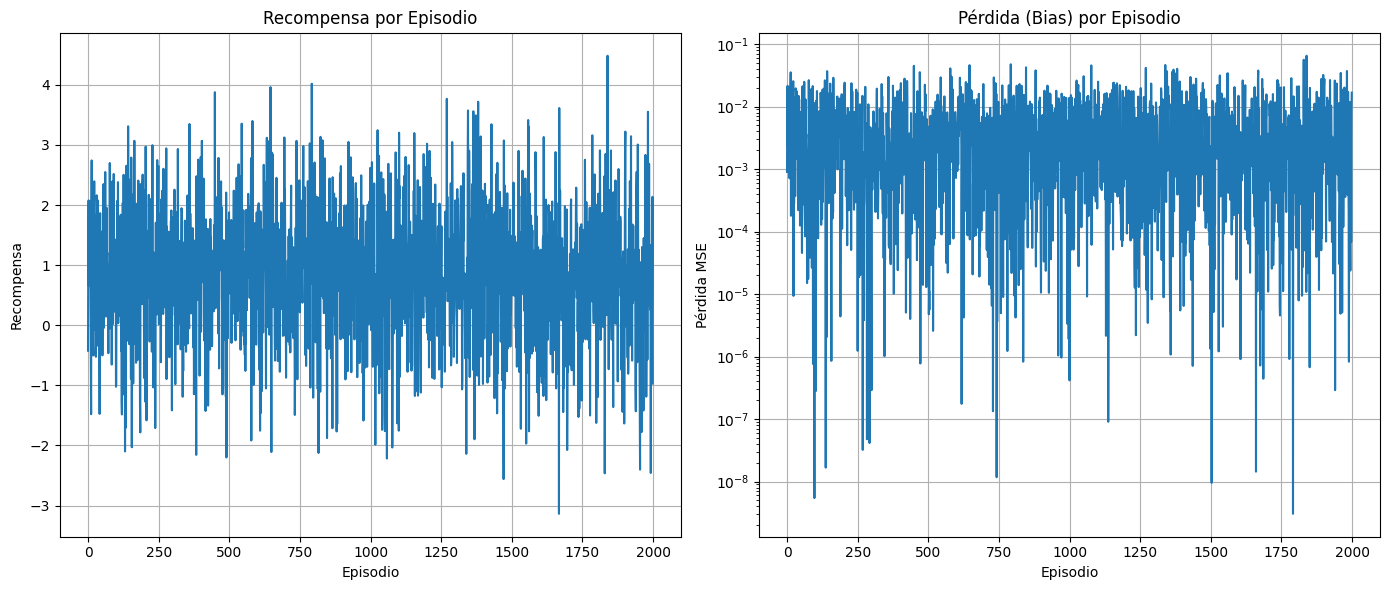

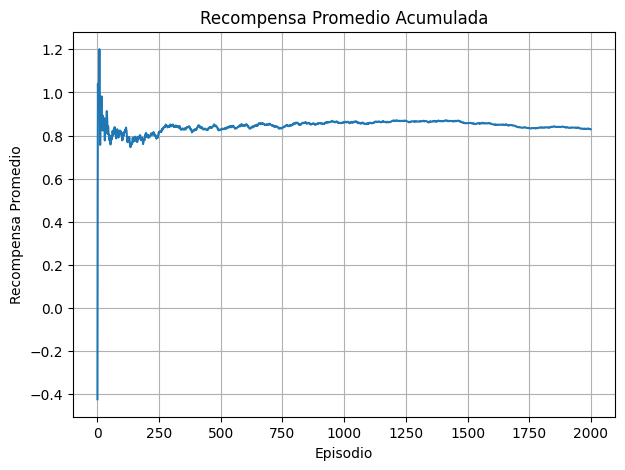

In [14]:
# --- Graficar Recompensas y Pérdida ---

plt.figure(figsize=(14, 6))

# Gráfico de Recompensas por Episodio
plt.subplot(1, 2, 1)
plt.plot(rewards_per_episode)
plt.title('Recompensa por Episodio')
plt.xlabel('Episodio')
plt.ylabel('Recompensa')
plt.grid(True)

# Gráfico de Pérdida por Episodio (Bias)
plt.subplot(1, 2, 2)
plt.plot(losses_per_episode)
plt.title('Pérdida (Bias) por Episodio')
plt.xlabel('Episodio')
plt.ylabel('Pérdida MSE')
plt.yscale('log') # Escala logarítmica para mejor visualización de la convergencia
plt.grid(True)

plt.tight_layout()
plt.show()

# Gráfico de Recompensa Promedio Acumulada
plt.figure(figsize=(7, 5))
cumulative_average_rewards = np.cumsum(rewards_per_episode) / (np.arange(len(rewards_per_episode)) + 1)
plt.plot(cumulative_average_rewards)
plt.title('Recompensa Promedio Acumulada')
plt.xlabel('Episodio')
plt.ylabel('Recompensa Promedio')
plt.grid(True)
plt.show()

### Uso de Entropía Cruzada para Comparar Resultados

Me preguntaste sobre el uso de la **entropía cruzada (Cross Entropy)**. Es importante entender cuándo se utiliza este tipo de función de pérdida.

*   La **Entropía Cruzada** se usa típicamente en problemas de **clasificación**, donde la red neuronal predice una distribución de probabilidad sobre varias clases (por ejemplo, la probabilidad de que una imagen sea un gato, perro, etc.). El objetivo es que la distribución de probabilidad predicha se parezca lo más posible a la distribución de probabilidad verdadera (one-hot encoded).

*   En nuestro problema de Bandido con Múltiples Brazos, estamos prediciendo un **valor numérico continuo** (el Q-value o la recompensa esperada) para cada acción. Esto es un problema de **regresión**. Para problemas de regresión, la función de pérdida más común y apropiada es el **Error Cuadrático Medio (Mean Squared Error - MSE)**, que es lo que hemos utilizado (`loss='mse'`). MSE mide la diferencia cuadrática entre el valor predicho y el valor real.

Si quisiéramos usar entropía cruzada en un problema de RL, tendríamos que redefinir el problema de una manera que implique una salida probabilística o una clasificación. Por ejemplo, podríamos tener una red neuronal que prediga directamente la probabilidad de elegir cada acción (una política estocástica). En ese caso, la entropía cruzada podría usarse para maximizar la probabilidad de las acciones que llevaron a recompensas altas.

Sin embargo, para el enfoque de 'valor' que hemos tomado aquí (donde la red predice directamente los Q-values), MSE es la elección correcta para minimizar la diferencia entre la predicción y el 'target' (la recompensa observada o el Q-value actualizado).

### Análisis de Resultados: 'Guess' vs 'Output' y Minimización del Bias

Durante el entrenamiento, la red neuronal de nuestro agente ha intentado **predecir ('guess')** los valores de recompensa esperados (Q-values) para cada acción. El **'output'** del entorno es la recompensa real obtenida después de que el agente toma una acción. El **'bias'** es la diferencia entre estos dos. El objetivo del entrenamiento es minimizar este bias, haciendo que las predicciones del agente se acerquen cada vez más a las recompensas medias verdaderas de cada brazo.

Podemos observar la convergencia del entrenamiento al comparar las estimaciones finales de los Q-values del agente con las recompensas medias verdaderas del entorno.

In [15]:
# --- Comparación de 'Guess' y 'Output' Finales ---
print("\n--- Comparación Final ---")

# Las recompensas medias verdaderas del entorno (el 'output' ideal)
print(f"Recompensas medias verdaderas del entorno: {environment.true_rewards}")

# Las estimaciones finales de Q-values del agente (su 'guess' final)
final_q_values = agent.model.predict(np.array([[0.0]]), verbose=0)[0]
print(f"Estimaciones finales de Q-values del agente: {final_q_values}")

# Calculamos el bias final (diferencia absoluta promedio)
final_bias = np.mean(np.abs(environment.true_rewards - final_q_values))
print(f"Bias promedio final (diferencia absoluta): {final_bias:.4f}")

# Identificamos el mejor brazo según el entorno y según el agente
best_true_arm = np.argmax(environment.true_rewards)
best_agent_arm = np.argmax(final_q_values)
print(f"Mejor brazo según el entorno: {best_true_arm} (recompensa: {environment.true_rewards[best_true_arm]:.2f})")
print(f"Mejor brazo elegido por el agente: {best_agent_arm} (estimación Q: {final_q_values[best_agent_arm]:.2f})")


--- Comparación Final ---
Recompensas medias verdaderas del entorno: [-0.90403259  0.92316045]
Estimaciones finales de Q-values del agente: [-0.96436405  0.8544698 ]
Bias promedio final (diferencia absoluta): 0.0645
Mejor brazo según el entorno: 1 (recompensa: 0.92)
Mejor brazo elegido por el agente: 1 (estimación Q: 0.85)


### Visualización del Aprendizaje: Recompensa y Pérdida (Bias)

Para entender cómo el agente minimizó el bias a lo largo del tiempo, podemos graficar las recompensas promedio por episodio y la función de pérdida (que es una medida del bias) durante el entrenamiento.

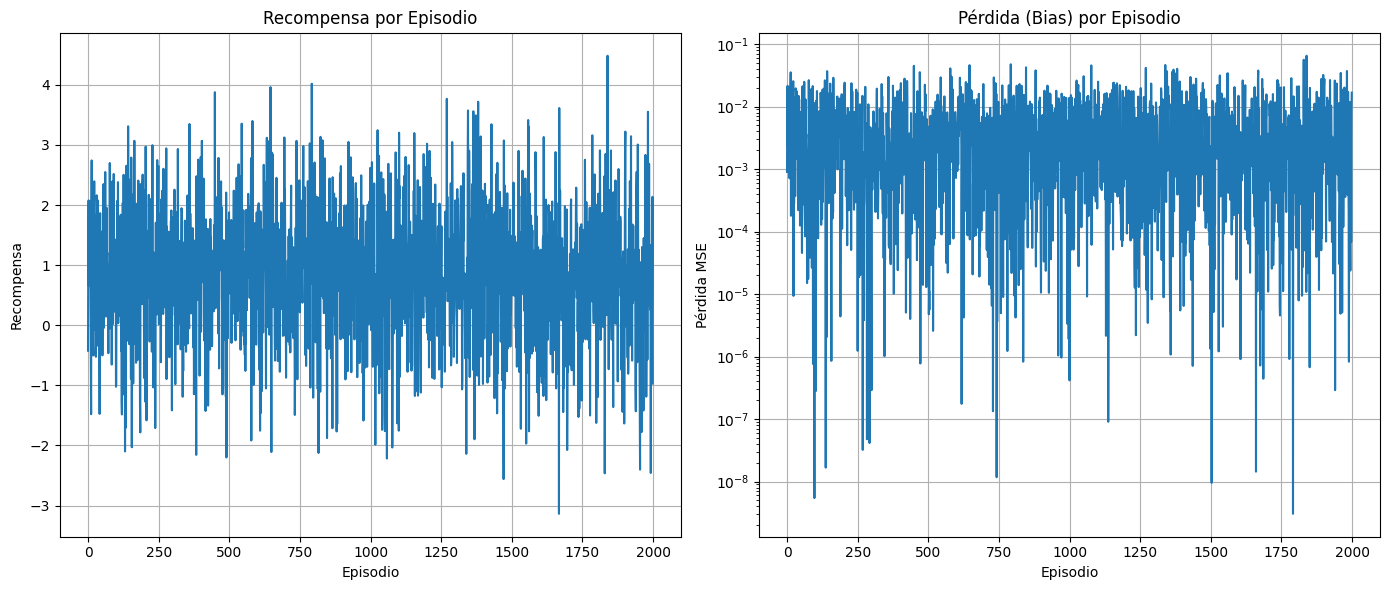

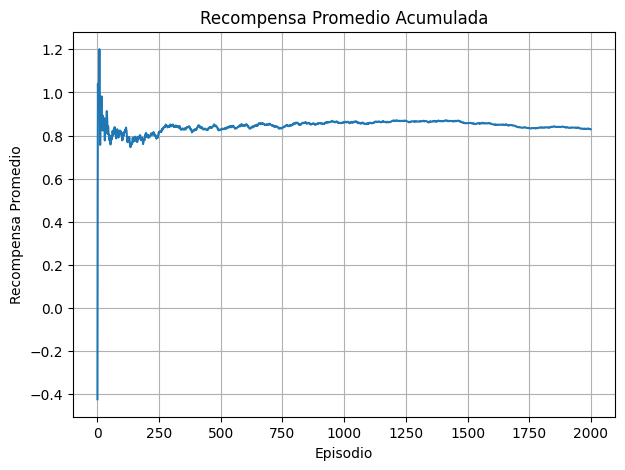

In [16]:
# --- Graficar Recompensas y Pérdida ---

plt.figure(figsize=(14, 6))

# Gráfico de Recompensas por Episodio
plt.subplot(1, 2, 1)
plt.plot(rewards_per_episode)
plt.title('Recompensa por Episodio')
plt.xlabel('Episodio')
plt.ylabel('Recompensa')
plt.grid(True)

# Gráfico de Pérdida por Episodio (Bias)
plt.subplot(1, 2, 2)
plt.plot(losses_per_episode)
plt.title('Pérdida (Bias) por Episodio')
plt.xlabel('Episodio')
plt.ylabel('Pérdida MSE')
plt.yscale('log') # Escala logarítmica para mejor visualización de la convergencia
plt.grid(True)

plt.tight_layout()
plt.show()

# Gráfico de Recompensa Promedio Acumulada
plt.figure(figsize=(7, 5))
cumulative_average_rewards = np.cumsum(rewards_per_episode) / (np.arange(len(rewards_per_episode)) + 1)
plt.plot(cumulative_average_rewards)
plt.title('Recompensa Promedio Acumulada')
plt.xlabel('Episodio')
plt.ylabel('Recompensa Promedio')
plt.grid(True)
plt.show()

### Uso de Entropía Cruzada para Comparar Resultados

Me preguntaste sobre el uso de la **entropía cruzada (Cross Entropy)**. Es importante entender cuándo se utiliza este tipo de función de pérdida.

*   La **Entropía Cruzada** se usa típicamente en problemas de **clasificación**, donde la red neuronal predice una distribución de probabilidad sobre varias clases (por ejemplo, la probabilidad de que una imagen sea un gato, perro, etc.). El objetivo es que la distribución de probabilidad predicha se parezca lo más posible a la distribución de probabilidad verdadera (one-hot encoded).

*   En nuestro problema de Bandido con Múltiples Brazos, estamos prediciendo un **valor numérico continuo** (el Q-value o la recompensa esperada) para cada acción. Esto es un problema de **regresión**. Para problemas de regresión, la función de pérdida más común y apropiada es el **Error Cuadrático Medio (Mean Squared Error - MSE)**, que es lo que hemos utilizado (`loss='mse'`). MSE mide la diferencia cuadrática entre el valor predicho y el valor real.

Si quisiéramos usar entropía cruzada en un problema de RL, tendríamos que redefinir el problema de una manera que implique una salida probabilística o una clasificación. Por ejemplo, podríamos tener una red neuronal que prediga directamente la probabilidad de elegir cada acción (una política estocástica). En ese caso, la entropía cruzada podría usarse para maximizar la probabilidad de las acciones que llevaron a recompensas altas.

Sin embargo, para el enfoque de 'valor' que hemos tomado aquí (donde la red predice directamente los Q-values), MSE es la elección correcta para minimizar la diferencia entre la predicción y el 'target' (la recompensa observada o el Q-value actualizado).

### Análisis de Resultados: 'Guess' vs 'Output' y Minimización del Bias

Durante el entrenamiento, la red neuronal de nuestro agente ha intentado **predecir ('guess')** los valores de recompensa esperados (Q-values) para cada acción. El **'output'** del entorno es la recompensa real obtenida después de que el agente toma una acción. El **'bias'** es la diferencia entre estos dos. El objetivo del entrenamiento es minimizar este bias, haciendo que las predicciones del agente se acerquen cada vez más a las recompensas medias verdaderas de cada brazo.

Podemos observar la convergencia del entrenamiento al comparar las estimaciones finales de los Q-values del agente con las recompensas medias verdaderas del entorno.

In [17]:
# --- Comparación de 'Guess' y 'Output' Finales ---
print("\n--- Comparación Final ---")

# Las recompensas medias verdaderas del entorno (el 'output' ideal)
print(f"Recompensas medias verdaderas del entorno: {environment.true_rewards}")

# Las estimaciones finales de Q-values del agente (su 'guess' final)
final_q_values = agent.model.predict(np.array([[0.0]]), verbose=0)[0]
print(f"Estimaciones finales de Q-values del agente: {final_q_values}")

# Calculamos el bias final (diferencia absoluta promedio)
final_bias = np.mean(np.abs(environment.true_rewards - final_q_values))
print(f"Bias promedio final (diferencia absoluta): {final_bias:.4f}")

# Identificamos el mejor brazo según el entorno y según el agente
best_true_arm = np.argmax(environment.true_rewards)
best_agent_arm = np.argmax(final_q_values)
print(f"Mejor brazo según el entorno: {best_true_arm} (recompensa: {environment.true_rewards[best_true_arm]:.2f})")
print(f"Mejor brazo elegido por el agente: {best_agent_arm} (estimación Q: {final_q_values[best_agent_arm]:.2f})")


--- Comparación Final ---
Recompensas medias verdaderas del entorno: [-0.90403259  0.92316045]
Estimaciones finales de Q-values del agente: [-0.96436405  0.8544698 ]
Bias promedio final (diferencia absoluta): 0.0645
Mejor brazo según el entorno: 1 (recompensa: 0.92)
Mejor brazo elegido por el agente: 1 (estimación Q: 0.85)


### Visualización del Aprendizaje: Recompensa y Pérdida (Bias)

Para entender cómo el agente minimizó el bias a lo largo del tiempo, podemos graficar las recompensas promedio por episodio y la función de pérdida (que es una medida del bias) durante el entrenamiento.

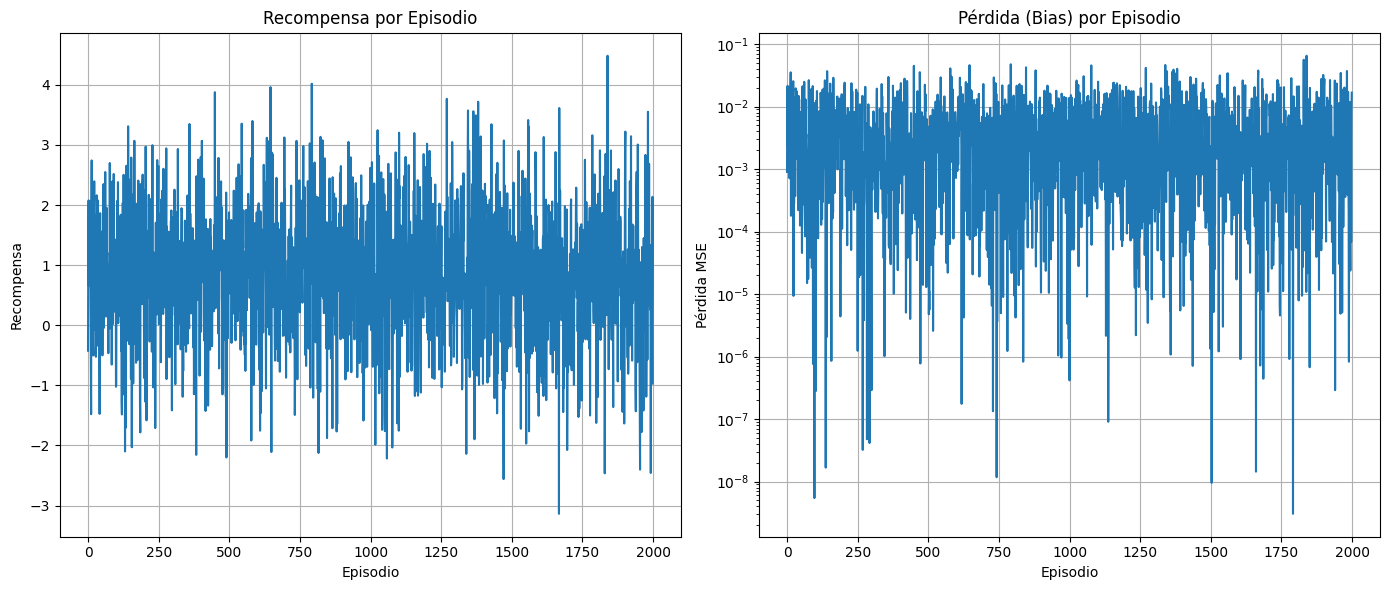

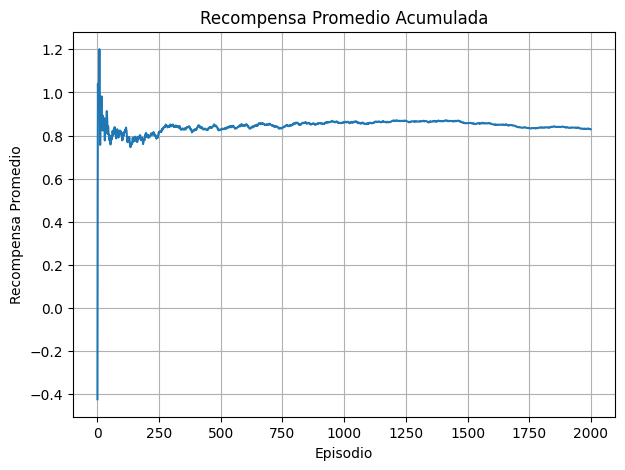

In [18]:
# --- Graficar Recompensas y Pérdida ---

plt.figure(figsize=(14, 6))

# Gráfico de Recompensas por Episodio
plt.subplot(1, 2, 1)
plt.plot(rewards_per_episode)
plt.title('Recompensa por Episodio')
plt.xlabel('Episodio')
plt.ylabel('Recompensa')
plt.grid(True)

# Gráfico de Pérdida por Episodio (Bias)
plt.subplot(1, 2, 2)
plt.plot(losses_per_episode)
plt.title('Pérdida (Bias) por Episodio')
plt.xlabel('Episodio')
plt.ylabel('Pérdida MSE')
plt.yscale('log') # Escala logarítmica para mejor visualización de la convergencia
plt.grid(True)

plt.tight_layout()
plt.show()

# Gráfico de Recompensa Promedio Acumulada
plt.figure(figsize=(7, 5))
cumulative_average_rewards = np.cumsum(rewards_per_episode) / (np.arange(len(rewards_per_episode)) + 1)
plt.plot(cumulative_average_rewards)
plt.title('Recompensa Promedio Acumulada')
plt.xlabel('Episodio')
plt.ylabel('Recompensa Promedio')
plt.grid(True)
plt.show()

### Uso de Entropía Cruzada para Comparar Resultados

Me preguntaste sobre el uso de la **entropía cruzada (Cross Entropy)**. Es importante entender cuándo se utiliza este tipo de función de pérdida.

*   La **Entropía Cruzada** se usa típicamente en problemas de **clasificación**, donde la red neuronal predice una distribución de probabilidad sobre varias clases (por ejemplo, la probabilidad de que una imagen sea un gato, perro, etc.). El objetivo es que la distribución de probabilidad predicha se parezca lo más posible a la distribución de probabilidad verdadera (one-hot encoded).

*   En nuestro problema de Bandido con Múltiples Brazos, estamos prediciendo un **valor numérico continuo** (el Q-value o la recompensa esperada) para cada acción. Esto es un problema de **regresión**. Para problemas de regresión, la función de pérdida más común y apropiada es el **Error Cuadrático Medio (Mean Squared Error - MSE)**, que es lo que hemos utilizado (`loss='mse'`). MSE mide la diferencia cuadrática entre el valor predicho y el valor real.

Si quisiéramos usar entropía cruzada en un problema de RL, tendríamos que redefinir el problema de una manera que implique una salida probabilística o una clasificación. Por ejemplo, podríamos tener una red neuronal que prediga directamente la probabilidad de elegir cada acción (una política estocástica). En ese caso, la entropía cruzada podría usarse para maximizar la probabilidad de las acciones que llevaron a recompensas altas.

Sin embargo, para el enfoque de 'valor' que hemos tomado aquí (donde la red predice directamente los Q-values), MSE es la elección correcta para minimizar la diferencia entre la predicción y el 'target' (la recompensa observada o el Q-value actualizado).